In [2]:
!pip install wordcloud
import pandas as pd
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Download small dictionaries nltk needs (only happens once, then it's cached)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [3]:

FAKE_NEWS_FILE = r"C:\Users\subha\Desktop\Fake (1).xls"
TRUE_NEWS_FILE = r"C:\Users\subha\Desktop\True.xls"

fake_df = pd.read_csv(FAKE_NEWS_FILE)
true_df = pd.read_csv(TRUE_NEWS_FILE)

print(f"Loaded {len(fake_df)} fake articles and {len(true_df)} real articles.")

Loaded 23481 fake articles and 21417 real articles.


In [4]:
 #We use: 1 = fake, 0 = real.

fake_df['label'] = 1
true_df['label'] = 0

# Stack both tables into one, then shuffle so fake/real are mixed randomly.
all_articles = pd.concat([fake_df, true_df], ignore_index=True)
all_articles = all_articles.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total combined articles: {len(all_articles)}")

Total combined articles: 44898


In [5]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Turn messy raw text into a clean list of important words."""
    text = str(text).lower()                              # lowercase everything
    text = re.sub(r'http\S+|www\S+', '', text)             # remove links
    text = re.sub(r'\S+@\S+', '', text)                    # remove emails
    text = re.sub(r'[^a-zA-Z\s]', '', text)                # remove numbers/symbols
    text = re.sub(r'\s+', ' ', text).strip()                # remove extra spaces

    words = word_tokenize(text)                            # split into individual words

    # Keep only meaningful words: drop common filler words ("the", "is", "and"...)
    # and reduce each word to its root form (e.g. "running" -> "run")
    important_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]
    return ' '.join(important_words)

print("Cleaning all article text... (this can take a minute)")
all_articles['combined_text'] = all_articles['title'] + ' ' + all_articles['text']
all_articles['cleaned_text'] = all_articles['combined_text'].apply(clean_text)
print("Done cleaning.")

Cleaning all article text... (this can take a minute)
Done cleaning.


In [6]:
X = all_articles['cleaned_text']   # the input: cleaned article text
y = all_articles['label']          # the answer key: 1=fake, 0=real

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training on {len(X_train)} articles, testing on {len(X_test)} articles.")

Training on 35918 articles, testing on 8980 articles.


In [7]:
model_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)),
    ('classifier', LogisticRegression(max_iter=1000))
])

print("Training the model...")
model_pipeline.fit(X_train, y_train)
print("Training complete.")

# Check how well it does on the articles it never saw during training
predictions = model_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"\nAccuracy on unseen test articles: {accuracy:.2%}")
print(classification_report(y_test, predictions, target_names=['Real News', 'Fake News']))

Training the model...
Training complete.

Accuracy on unseen test articles: 98.91%
              precision    recall  f1-score   support

   Real News       0.99      0.99      0.99      4284
   Fake News       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



## Visualizations

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

sns.set_style('whitegrid')

### 1. Fake vs Real article counts

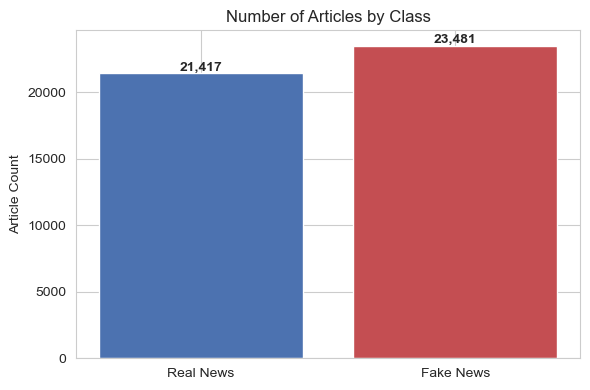

In [9]:
counts = all_articles['label'].value_counts().sort_index()
labels = ['Real News', 'Fake News']
colors = ['#4C72B0', '#C44E52']

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, counts.values, color=colors)
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{count:,}', ha='center', fontweight='bold')
plt.title('Number of Articles by Class')
plt.ylabel('Article Count')
plt.tight_layout()
plt.show()

### 3. Confusion matrix (test set predictions)

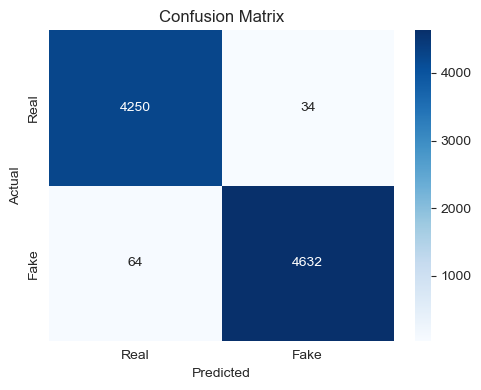

In [11]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Model Comparison: Naive Bayes vs Logistic Regression vs Linear SVM vs Random Forest



In [14]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
import time

### Fit a shared TF-IDF representation (same params used before) so every model sees identical features

In [15]:
shared_tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
X_train_tfidf = shared_tfidf.fit_transform(X_train)
X_test_tfidf = shared_tfidf.transform(X_test)

print(f"TF-IDF matrix shape -> train: {X_train_tfidf.shape}, test: {X_test_tfidf.shape}")

TF-IDF matrix shape -> train: (35918, 5000), test: (8980, 5000)


### Train each model and collect metrics

In [16]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM': LinearSVC(max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

results = []
trained_models = {}

for name, clf in models.items():
    print(f"Training {name}...")
    start = time.time()
    clf.fit(X_train_tfidf, y_train)
    elapsed = time.time() - start

    preds = clf.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    report = classification_report(
        y_test, preds, target_names=['Real News', 'Fake News'], output_dict=True
    )

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (Fake)': report['Fake News']['precision'],
        'Recall (Fake)': report['Fake News']['recall'],
        'F1 (Fake)': report['Fake News']['f1-score'],
        'Train Time (s)': round(elapsed, 2)
    })
    trained_models[name] = clf

print("Done training all models.")

Training Naive Bayes...
Training Logistic Regression...
Training Linear SVM...
Training Random Forest...
Done training all models.


### Comparison table (sorted by accuracy, best first)

In [17]:
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision (Fake),Recall (Fake),F1 (Fake),Train Time (s)
0,Random Forest,0.997884,0.998933,0.997019,0.997975,61.74
1,Linear SVM,0.995768,0.995532,0.996380,0.995956,3.01
2,Logistic Regression,0.989087,0.992713,0.986371,0.989532,1.41
3,Naive Bayes,0.942873,0.945474,0.945273,0.945373,0.12


### Accuracy comparison chart

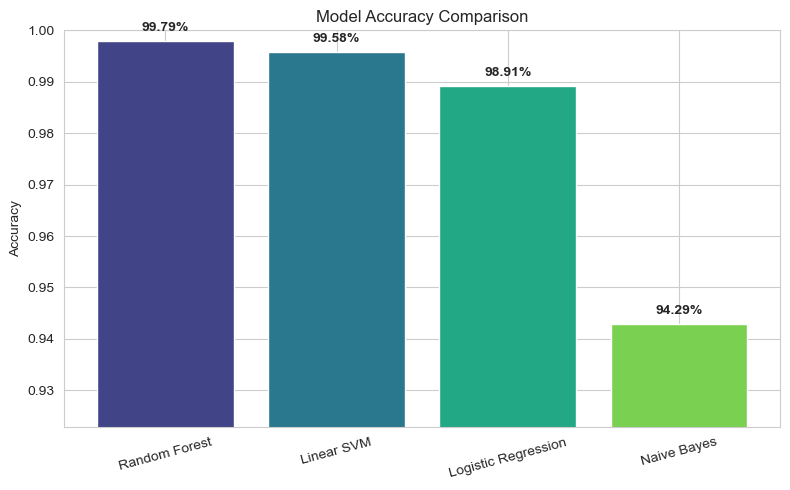

In [18]:
plt.figure(figsize=(8, 5))
palette = sns.color_palette('viridis', len(results_df))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=palette)
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.2%}', ha='center', fontweight='bold')
plt.ylim(min(results_df['Accuracy']) - 0.02, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Precision / Recall / F1 comparison (for the Fake News class)

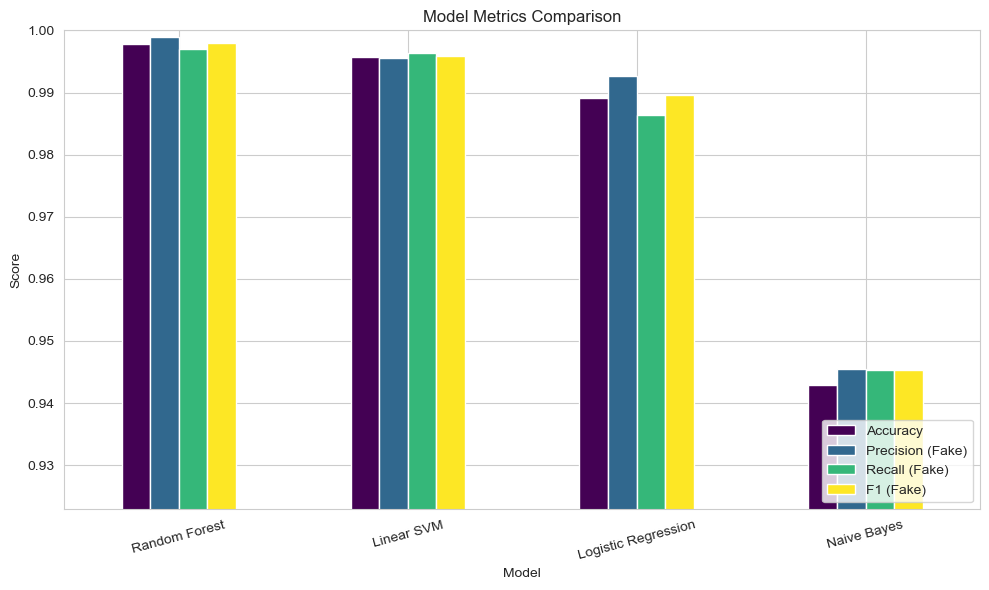

In [19]:
metrics_df = results_df.set_index('Model')[['Accuracy', 'Precision (Fake)', 'Recall (Fake)', 'F1 (Fake)']]

ax = metrics_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Model Metrics Comparison')
plt.ylabel('Score')
plt.ylim(min(metrics_df.min()) - 0.02, 1.0)
plt.legend(loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Confusion matrix for every model, side by side

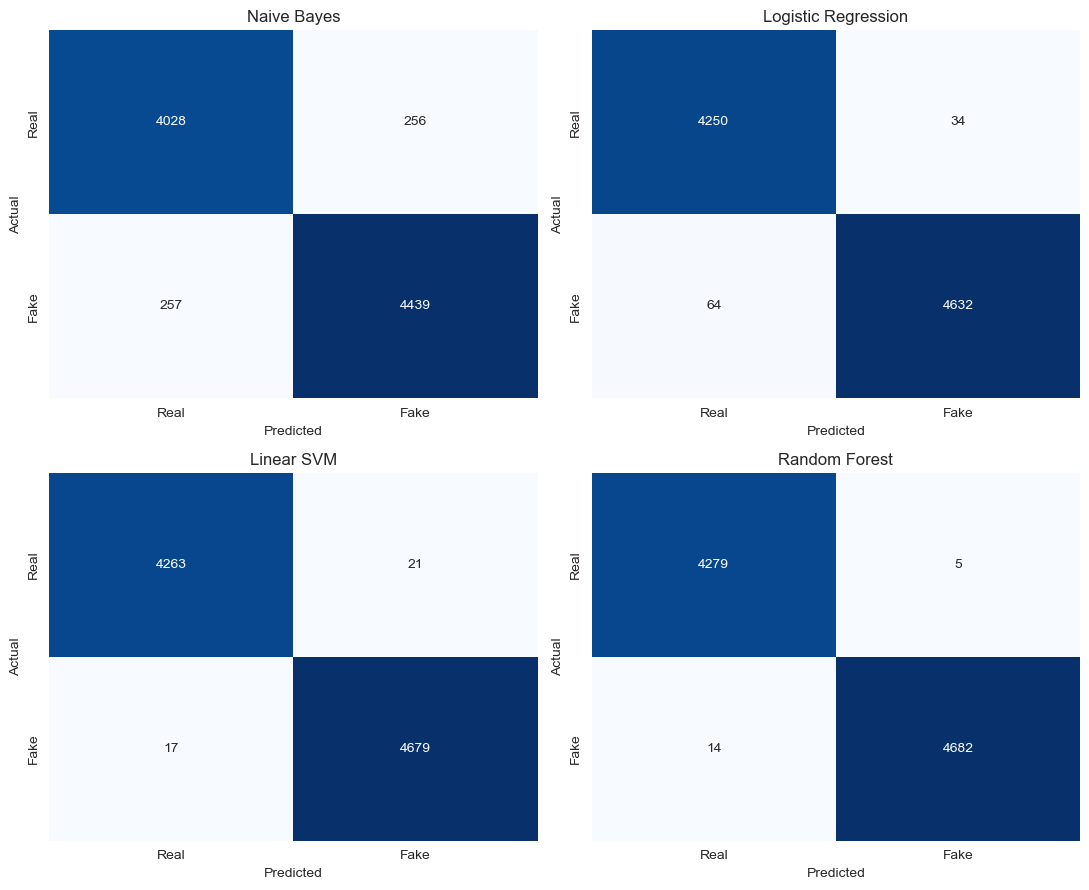

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for ax, (name, clf) in zip(axes.flatten(), trained_models.items()):
    preds = clf.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Winner

In [21]:
best_row = results_df.iloc[0]
print(f"Best performing model: {best_row['Model']}")
print(f"  Accuracy:  {best_row['Accuracy']:.2%}")
print(f"  Precision: {best_row['Precision (Fake)']:.2%}")
print(f"  Recall:    {best_row['Recall (Fake)']:.2%}")
print(f"  F1-score:  {best_row['F1 (Fake)']:.2%}")
print(f"  Train time: {best_row['Train Time (s)']}s")

Best performing model: Random Forest
  Accuracy:  99.79%
  Precision: 99.89%
  Recall:    99.70%
  F1-score:  99.80%
  Train time: 61.74s


In [22]:
def check_article(title, text):
    """Check whether a news article is real or fake."""
    combined = f"{title} {text}"
    cleaned = clean_text(combined)

    prediction = model_pipeline.predict([cleaned])[0]
    probabilities = model_pipeline.predict_proba([cleaned])[0]
    confidence = max(probabilities)

    label = "FAKE NEWS" if prediction == 1 else "REAL NEWS"

    print(f"\nTitle: {title}")
    print(f"Result: {label}")
    print(f"Confidence: {confidence:.1%}")
    return {'result': label, 'confidence': confidence}

In [23]:
print("\n" + "=" * 50)
print("TESTING SOME SAMPLE ARTICLES")
print("=" * 50)

check_article(
    title="Scientists Discover New Treatment for Cancer",
    text="Researchers at Stanford University have published results showing "
         "a 90% success rate in treating advanced-stage cancer using a new "
         "immunotherapy approach."
)

check_article(
    title="ALIENS LAND IN NEW YORK - Government Cover-Up Exposed!",
    text="BREAKING: Multiple witnesses reported seeing UFOs landing in Times "
         "Square. The government is hiding the truth. Share before they delete it!"
)


TESTING SOME SAMPLE ARTICLES

Title: Scientists Discover New Treatment for Cancer
Result: FAKE NEWS
Confidence: 68.5%

Title: ALIENS LAND IN NEW YORK - Government Cover-Up Exposed!
Result: FAKE NEWS
Confidence: 93.2%


{'result': 'FAKE NEWS', 'confidence': np.float64(0.9316042158630885)}

In [28]:
def interactive_check():
    """Keep asking for articles to check until you type 'quit'."""
    print("\nType 'quit' at any time to stop.")
    while True:
        title = input("\nEnter news title: ")
        if title.lower() == 'quit':
            break
        text = input("Enter news text: ")
        if text.lower() == 'quit':
            break
        check_article(title, text)

# Uncomment to run interactive mode
interactive_check()


Type 'quit' at any time to stop.



Enter news title:  PM Shah pledges action on construction sector's long-standing issues
Enter news text:  Enter news text:  KATHMANDU, JULY 9Prime Minister Balendra Shah has assured construction entrepreneurs that the government is committed to resolving long-standing challenges facing the infrastructure sector to accelerate development and support economic growth. During a meeting with officials of the Federation of Contractors' Associations of Nepal (FCAN) on Thursday, Shah said a strong construction sector is vital for infrastructure development, employment generation and investment, adding that the government is working to create a more business-friendly environment.He stressed the need for close cooperation between the government and the private sector to ensure timely completion of development projects while promoting greater transparency, accountability and efficiency in infrastructure works. FCAN representatives raised concerns over delayed payments, contract management, proje


Title: PM Shah pledges action on construction sector's long-standing issues
Result: REAL NEWS
Confidence: 91.8%



Enter news title:  quit


In [25]:
with open('fake_news_model.pkl', 'wb') as f:
    pickle.dump(model_pipeline, f)
print("\nModel saved to fake_news_model.pkl")


Model saved to fake_news_model.pkl
